# 3b · Why change coordinates at all?

**Companion to notebook 3 — the "why" behind each operation.**

Short answer to the question that prompted this: **yes, exactly that.**
$[M]\{\ddot q\}+[K]\{q\}=\{f(t)\}$ is kept, and all that happens is a **change of
coordinates**: instead of describing the motion by physical displacements
$\{q\}$, describe it by *how much of each natural mode* is present,
$\{q\}=[\Phi]\{\eta\}$. Nothing is approximated and nothing is thrown away —
$[\Phi]$ is invertible, so the two descriptions carry identical information.

What is *gained* is that in this particular basis the equations stop talking to
each other. This notebook covers, in order:

1. why the modal basis and not some other basis,
2. why the three operations (substitute → pre-multiply by $[\Phi]^\mathsf{T}$ →
   read a row) are the only ones needed,
3. why $[M]$ appears in $\{u^s\}^\mathsf{T}[M]\{u^r\}$ but **not** in
   $\{u^r\}^\mathsf{T}\{f\}$,
4. what the decoupling buys in forced response — which is where the paper's
   design idea lives,
5. what the transformation does *not* give you for free.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

try:                                    # use the series style if primer.py is next door
    import primer
    from primer import SERIES, INK, INK2, GRID, tidy
    primer.use_style()
except ModuleNotFoundError:             # ...otherwise stay standalone
    SERIES = ["#2f6f9f", "#b4593b", "#4a7c59", "#8b6f9e"]
    INK = INK2 = "#222222"
    GRID = "#c0c0c0"
    def tidy(ax, title="", xlabel="", ylabel=""):
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25)

# same 2-DOF chain as notebook 3, so every number is comparable
m1, m2 = 2.0, 1.0
k1, k2 = 800.0, 400.0
M = np.diag([m1, m2])
K = np.array([[k1 + k2, -k2], [-k2, k2]])

w2, V = eigh(K, M)
V = V / V[np.argmax(np.abs(V), axis=0), np.arange(2)]     # largest entry = 1
omega = np.sqrt(w2)

print("omega =", np.round(omega, 3), "rad/s   ->  f =", np.round(omega / (2*np.pi), 3), "Hz")
print("Phi =\n", np.round(V, 4))

omega = [14.142 28.284] rad/s   ->  f = [2.251 4.502] Hz
Phi =
 [[ 0.5  1. ]
 [ 1.  -1. ]]


## 3b.1 · Why *this* basis

A change of coordinates $\{q\}=[T]\{\eta\}$ with any invertible $[T]$ is legal.
Substituting and pre-multiplying by $[T]^\mathsf{T}$ always gives

$$[T]^\mathsf{T}[M][T]\{\ddot\eta\}+[T]^\mathsf{T}[K][T]\{\eta\}=[T]^\mathsf{T}\{f\}$$

so the *form* survives for every $[T]$. What almost no $[T]$ does is make **both**
transformed matrices diagonal at once. Any single symmetric matrix can be
diagonalised in many ways; simultaneous diagonalisation of the *pair*
$([M],[K])$ is special, and the basis that does it is precisely the set of
eigenvectors of $[K]\{u\}=\omega^2[M]\{u\}$.

So the logic runs backwards from the goal: *"I want the equations to decouple"*
$\Rightarrow$ *"I need a basis that diagonalises M and K together"*
$\Rightarrow$ *"that basis is the mode shapes"*. Orthogonality is not a curious
property of modes that someone noticed afterwards; it **is** the defining
property, restated.

Below, the residual coupling in three candidate bases. The numbers are
normalised, $|A_{12}|/\sqrt{A_{11}A_{22}}$, because the raw entries mix units and
a bare "is it small" test on them is meaningless.

In [2]:
def coupling(A):
    # dimensionless off-diagonal coupling coefficient, |A12| / sqrt(A11*A22)
    d = np.sqrt(np.abs(np.diag(A)))
    return abs(A[0, 1] / (d[0] * d[1]))

rng = np.random.default_rng(0)
bases = {
    "physical  (T = I)":        np.eye(2),
    "random invertible T":      rng.normal(size=(2, 2)),
    "modal     (T = Phi)":      V,
}

print(f"{'basis':24s} {'coupling in M':>14s} {'coupling in K':>14s}")
for name, T in bases.items():
    Mt, Kt = T.T @ M @ T, T.T @ K @ T
    print(f"{name:24s} {coupling(Mt):14.2e} {coupling(Kt):14.2e}")

print("\nThe physical basis already diagonalises M (the masses are lumped) but")
print("not K.  A random basis ruins both.  Only Phi kills both at once.")

basis                     coupling in M  coupling in K
physical  (T = I)              0.00e+00       5.77e-01
random invertible T            2.38e-01       5.40e-01
modal     (T = Phi)            5.23e-17       1.67e-16

The physical basis already diagonalises M (the masses are lumped) but
not K.  A random basis ruins both.  Only Phi kills both at once.


## 3b.2 · The three operations, and what each one is for

**(1) Substitute $\{q\}=[\Phi]\{\eta\}$ — completeness.**
The $n$ mode shapes are linearly independent, so they span the whole
configuration space: *every* possible motion of the system, forced or free,
transient or steady, is some combination of them. That is what licenses the
substitution as an identity rather than an assumption. The modal coordinate
$\eta_r(t)$ is a scalar amplitude, "how much of mode $r$ is going on right now".

**(2) Pre-multiply by $[\Phi]^\mathsf{T}$ — this is the step that does the work.**
Substituting alone gives $[M][\Phi]\{\ddot\eta\}+[K][\Phi]\{\eta\}=\{f\}$, which
is still fully coupled. The left multiplication is what lets orthogonality act,
because $\{u^s\}^\mathsf{T}[M]\{u^r\}=0$ can only be used if there is a
$\{u^s\}^\mathsf{T}$ sitting in front. Row $s$ of the result is literally
"project the whole vector equation onto mode $s$".

*Why the transpose and not the inverse?* $[\Phi]^{-1}$ would also decouple things
(indeed $[\Phi]^{-1}=[\,\mathrm{diag}\,m_r]^{-1}[\Phi]^\mathsf{T}[M]$), but
$[\Phi]^\mathsf{T}(\cdot)[\Phi]$ is a **congruence** transform: it preserves
symmetry and positive-definiteness, it costs no inverse, and every scalar it
produces is an energy or a work. $[\Phi]^{-1}(\cdot)[\Phi]$ is a similarity
transform: same eigenvalues, but the matrices lose symmetry and the entries stop
meaning anything physical.

**(3) Read off row $r$.** What is left is
$m_r\ddot\eta_r+k_r\eta_r=\{u^r\}^\mathsf{T}\{f\}$: one mass, one spring, one
force. Solve $n$ of those independently and add up the answers.

## 3b.3 · Why $[M]$ appears in one product and not the other

This is the part that reads as inconsistent until it doesn't. Compare

$$\underbrace{\{u^s\}^\mathsf{T}[M]\{u^r\}}_{\text{needs }[M]}\qquad\text{vs.}\qquad
\underbrace{\{u^r\}^\mathsf{T}\{f\}}_{\text{no }[M]}$$

Both are pairings of two vectors, but the vectors are of *different kinds*:

* $\{u^r\}$ and $\{u^s\}$ are both **motions**. To compare two motions you need a
  metric, and physics supplies one: kinetic energy. $\{u^s\}^\mathsf{T}[M]\{u^r\}$
  is (twice) the kinetic-energy cross term. Without $[M]$ you would be adding
  metres to radians and the plain dot product of the two mode shapes is just a
  number with no meaning — as notebook 3 shows by printing it.
* $\{u^r\}$ is a **motion** and $\{f\}$ is a **force**. Their product is already
  work, $\text{N}\cdot\text{m}$, regardless of what units the entries carry. No
  metric is needed or allowed — inserting $[M]$ there would be a units error.

Rule of thumb: *motion with motion needs $[M]$ or $[K]$ in the middle; motion
with force does not.* Forces live in the dual space, and the pairing between a
space and its dual is free.

In [3]:
# Energy is additive over modes.  Take an arbitrary state, split it, check.
q  = np.array([0.013, -0.004])
qd = np.array([0.20,  0.35])

eta  = np.linalg.solve(V, q)
etad = np.linalg.solve(V, qd)
mr = np.diag(V.T @ M @ V)
kr = np.diag(V.T @ K @ V)

T_phys, U_phys = 0.5 * qd @ M @ qd, 0.5 * q @ K @ q
T_mod,  U_mod  = 0.5 * np.sum(mr * etad**2), 0.5 * np.sum(kr * eta**2)

print(f"kinetic:  physical {T_phys:.8f}   sum over modes {T_mod:.8f}")
print(f"strain :  physical {U_phys:.8f}   sum over modes {U_mod:.8f}")
print("\nNo cross terms between modes appear in either energy -- that IS the")
print("orthogonality statement, and it is why 'independent oscillators' is")
print("literal rather than a figure of speech.")

# units check on the two pairings
print("\nu2^T M u1 =", f"{V[:,1] @ M @ V[:,0]:.2e}", " (motion-motion, needs M)")
print("u1^T f    =", f"{V[:,0] @ np.array([1.0, 0.0]):.4f}", " (motion-force, no M)")

kinetic:  physical 0.10125000   sum over modes 0.10125000
strain :  physical 0.12540000   sum over modes 0.12540000

No cross terms between modes appear in either energy -- that IS the
orthogonality statement, and it is why 'independent oscillators' is
literal rather than a figure of speech.

u2^T M u1 = -1.11e-16  (motion-motion, needs M)
u1^T f    = 0.5000  (motion-force, no M)


## 3b.4 · A shortcut that only orthogonality makes possible

Notebook 3 got the modal initial conditions with `np.linalg.solve(Phi, q0)`.
That is correct but it hides the point. Because the modes are
$[M]$-orthogonal, each amplitude can be **projected out one at a time**:

$$\eta_r(0)=\frac{\{u^r\}^\mathsf{T}[M]\{q_0\}}{m_r}$$

No linear system, no reference to the other modes. This matters far beyond
neatness: in a real model with $10^5$ DOF you never form $[\Phi]$, let alone
invert it. You compute the handful of modes you care about and project onto them
individually. The same projection is what "modal participation" means, and it is
the operation the next notebook turns into a design condition.

In [4]:
q0 = np.array([0.01, 0.0])

eta_solve = np.linalg.solve(V, q0)                      # solve the linear system
eta_proj  = (V.T @ M @ q0) / mr                         # project, mode by mode

print("via linear solve :", eta_solve)
print("via projection   :", eta_proj)
print("difference       :", np.max(np.abs(eta_solve - eta_proj)))

via linear solve : [0.0067 0.0067]
via projection   : [0.0067 0.0067]
difference       : 1.734723475976807e-18


## 3b.5 · What the decoupling buys: forced response

This is where the change of coordinates stops being bookkeeping. With harmonic
forcing $\{f\}=\{F\}e^{i\omega t}$ each modal oscillator responds on its own, so
the full response is a **sum of $n$ single-DOF resonance curves**:

$$\{q(\omega)\}=\sum_{r=1}^{n}\{u^r\}\,
\frac{\{u^r\}^\mathsf{T}\{F\}}{k_r-\omega^2 m_r+i\omega c_r}$$

Read the fraction carefully, because the whole paper is in it:

* the **denominator** is the mode's own dynamics. Isolation design works here, by
  pushing $\omega_r$ away from $\omega$. It always costs stiffness.
* the **numerator** $\{u^r\}^\mathsf{T}\{F\}$ is how strongly the load shape
  overlaps the mode shape — the *participation factor*. It is a property of the
  pairing of load and mode, not of frequency.

A zero numerator removes that mode's contribution at **every** $\omega$, the
resonance included, where the denominator is down to damping alone and can no
longer help. That is the escape hatch Furusawa uses: not "move the mode" but
"arrange for the excitation not to see it".

(The sum below is exact because the damping is chosen proportional,
$[C]=\alpha[M]+\beta[K]$, so $[\Phi]^\mathsf{T}[C][\Phi]$ is diagonal too. See
3b.6 for what happens when it is not.)

modal damping ratios: [0.0214 0.0109]
max |direct - modal sum| = 3.3617848912307505e-16


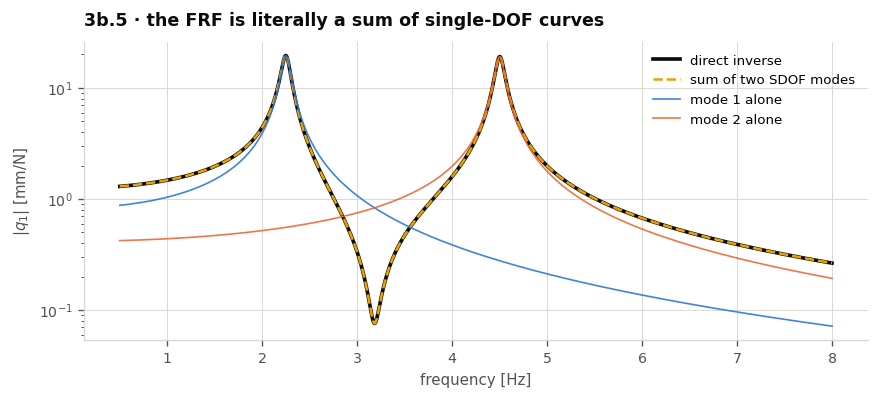

In [5]:
alpha, beta = 0.6, 2.0e-5
C = alpha * M + beta * K                       # proportional -> also diagonalised by Phi
cr = np.diag(V.T @ C @ V)
zeta = cr / (2 * mr * omega)
print("modal damping ratios:", np.round(zeta, 4))

f_hz = np.linspace(0.5, 8.0, 1500)
w = 2 * np.pi * f_hz

F1 = np.array([1.0, 0.0])                      # force on mass 1 only

def frf_direct(F):
    return np.array([np.linalg.solve(K + 1j*wi*C - wi**2*M, F) for wi in w])

def frf_modal(F, modes=(0, 1)):
    out = np.zeros((len(w), 2), complex)
    for r in modes:
        p = V[:, r] @ F                                            # participation
        out += np.outer(p / (kr[r] - w**2*mr[r] + 1j*w*cr[r]), V[:, r])
    return out

H_d, H_m = frf_direct(F1), frf_modal(F1)
print("max |direct - modal sum| =", np.max(np.abs(H_d - H_m)))

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.semilogy(f_hz, np.abs(H_d[:, 0]) * 1000, color=INK, lw=2.2, label="direct inverse")
ax.semilogy(f_hz, np.abs(H_m[:, 0]) * 1000, color=SERIES[3], ls="--", lw=1.5,
            label="sum of two SDOF modes")
for r in range(2):
    ax.semilogy(f_hz, np.abs(frf_modal(F1, modes=(r,))[:, 0]) * 1000,
                color=SERIES[r], lw=1.0, alpha=0.9, label=f"mode {r+1} alone")
tidy(ax, "3b.5 · the FRF is literally a sum of single-DOF curves",
     "frequency [Hz]", "$|q_1|$ [mm/N]")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### The same plot, with the numerator switched off

Mode 2 disappears from the response if the load is chosen so that
$\{u^2\}^\mathsf{T}\{F\}=0$. Note what this condition is *not*: it is not
$\{F\}\parallel\{u^1\}$, and it involves no $[M]$ — it is the plain
motion–force pairing of 3b.3. In the mount problem the same sentence reads: the
excitation is the primary inertia couple, mode 2 is pure yaw, and
$\{u^2\}^\mathsf{T}\{F\}=0$ becomes the paper's Eq. (16).

F on mass 1              participation |u_r^T F| = [0.5 1. ]   normalised = [0.4082 0.5774]
F orthogonal to mode 2   participation |u_r^T F| = [-1.0607  0.    ]   normalised = [0.866 0.   ]


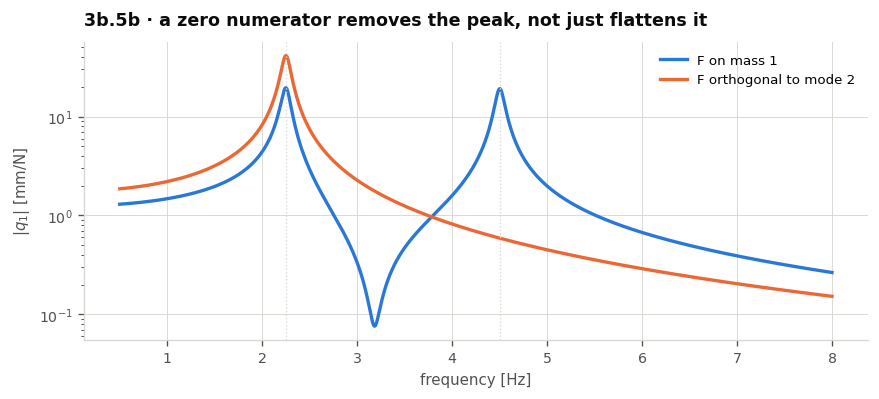


The second resonance is still there in the system -- same M, same K, same
omega_2.  It simply is not excited.  Damping was never touched.


In [6]:
u2 = V[:, 1]
F_orth = np.array([u2[1], -u2[0]])                 # any F with u2 . F = 0
F_orth = F_orth / np.linalg.norm(F_orth)

for name, F in (("F on mass 1", F1), ("F orthogonal to mode 2", F_orth)):
    p = V.T @ F
    p_norm = np.abs(p) / (np.sqrt(mr) * np.linalg.norm(F))       # dimensionless
    print(f"{name:24s} participation |u_r^T F| = {np.round(p, 4)}   "
          f"normalised = {np.round(p_norm, 4)}")

fig, ax = plt.subplots(figsize=(7.4, 3.4))
for (name, F), c in zip((("F on mass 1", F1), ("F orthogonal to mode 2", F_orth)),
                        (SERIES[0], SERIES[1])):
    H = frf_direct(F)
    ax.semilogy(f_hz, np.abs(H[:, 0]) * 1000, color=c, lw=2.0, label=name)
for r in range(2):
    ax.axvline(omega[r] / (2*np.pi), color=GRID, lw=0.8, ls=":")
tidy(ax, "3b.5b · a zero numerator removes the peak, not just flattens it",
     "frequency [Hz]", "$|q_1|$ [mm/N]")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nThe second resonance is still there in the system -- same M, same K, same")
print("omega_2.  It simply is not excited.  Damping was never touched.")

## 3b.6 · The small print

Four things the change of coordinates does **not** hand over for free.

1. **Damping.** $[\Phi]$ was built from $([M],[K])$ only, so there is no reason
   for $[\Phi]^\mathsf{T}[C][\Phi]$ to be diagonal. It is diagonal for
   proportional (Rayleigh/Caughey) damping, which is an assumption, not a
   theorem. Otherwise the modes stay coupled through damping, the modes go
   complex, and "mode 2 is pure yaw" has to be re-read as a statement about a
   complex mode. Rubber bushes with real loss factors are exactly the case where
   this needs checking.
2. **Linearity and constant coefficients.** The whole construction assumes
   $[M]$ and $[K]$ fixed. Amplitude-dependent bush rates, preload changes, or
   large rotations invalidate the basis rather than perturb it.
3. **Repeated frequencies.** The orthogonality proof divided by
   $\omega_r^2-\omega_s^2$. With $\omega_r=\omega_s$ any basis of that
   eigen-subspace is valid and `eigh` returns an arbitrary one — fine
   numerically, dangerous when the design *means* something specific by "mode 2".
   This is also why a near-degenerate pair makes an orthogonality design fragile:
   mode-shape sensitivity carries $1/(\omega_r^2-\omega_s^2)$.
4. **Truncation.** Keeping a few modes is an approximation even though the
   transformation is not. What gets lost is mostly static flexibility, which is
   what residual-flexibility or Craig–Bampton corrections put back.

In [7]:
# Non-proportional damping: one dashpot across the second spring only.
C_np = np.array([[ 4.0, -4.0],
                 [-4.0,  4.0]])
Cm_prop, Cm_np = V.T @ C @ V, V.T @ C_np @ V

print("Phi^T C Phi, proportional damping:\n", np.round(Cm_prop, 6))
print("\nPhi^T C Phi, one dashpot on k2:\n", np.round(Cm_np, 6))
print("\nnormalised off-diagonal:  proportional", f"{coupling(Cm_prop):.2e}",
      "   non-proportional", f"{coupling(Cm_np):.2e}")
print("\nSecond case: the modes still diagonalise M and K, but not C, so they are")
print("no longer independent oscillators.  Check this before trusting a modal")
print("model of a rubber-mounted system.")

Phi^T C Phi, proportional damping:
 [[ 0.906 -0.   ]
 [-0.     1.848]]

Phi^T C Phi, one dashpot on k2:
 [[ 1. -4.]
 [-4. 16.]]

normalised off-diagonal:  proportional 8.58e-17    non-proportional 1.00e+00

Second case: the modes still diagonalise M and K, but not C, so they are
no longer independent oscillators.  Check this before trusting a modal
model of a rubber-mounted system.


## Summary — notebook 3's operations, and why

| operation in notebook 3 | what it is for |
|---|---|
| $\{q\}=[\Phi]\{\eta\}$ | change of basis; legal because the modes span the space |
| pre-multiply by $[\Phi]^\mathsf{T}$ | projects the vector equation onto one mode at a time; congruence keeps symmetry and energy meaning |
| $\{u^s\}^\mathsf{T}[M]\{u^r\}=0$ | no kinetic-energy cross term; the metric is mass because both arguments are motions |
| diagonal of $[\Phi]^\mathsf{T}[M][\Phi]$ | modal mass $m_r$; scale-dependent bookkeeping, cancels in every physical answer |
| $\{u^r\}^\mathsf{T}\{f\}$ | modal force; a work pairing, so no $[M]$ |
| $k_r/m_r=\omega_r^2$ | each decoupled equation is one mass on one spring |

And the one sentence that carries into the paper: decoupling turns the response
into a sum of terms with an *excitation-dependent numerator* over a
*frequency-dependent denominator*, and the numerator can be designed to zero.

**Next:** [4 · Participation, and how to silence a mode](04_participation_and_silent_modes.ipynb)